# Deep Creativity scoring of compositional-diffusion samples
Scores `generated_compose_{average,product}.pt` with `DeepCreativity` for both `use_discriminator=False` (is_digit CNN) and `use_discriminator=True`. Saves the top 50 per config and displays them.

In [11]:
import sys
from pathlib import Path

ROOT = Path('/u/zup7mn/Classes/NN/digit4')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from src.metrics import DeepCreativity

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
HERE = ROOT / 'src/diffusion/v3_score'
print('device:', device)

device: cuda:0


In [12]:
# Mirror the architecture from /u/zup7mn/Classes/NN/digit4/mnist_VAE.ipynb so full_VAE.pth loads.
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.flatten = nn.Flatten()
        self.first_hidden = nn.Linear(input_dim, hidden_dim)
        self.second_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.var = nn.Linear(hidden_dim, latent_dim)
        self.activation = nn.LeakyReLU()
    def forward(self, x):
        y = self.activation(self.first_hidden(self.flatten(x)))
        y = self.activation(self.second_hidden(y))
        return self.mean(y), self.var(y)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.first_hidden = nn.Linear(latent_dim, hidden_dim)
        self.second_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.activation(self.first_hidden(x))
        y = self.activation(self.second_hidden(y))
        return self.sigmoid(self.output(y))

class VAE(nn.Module):
    def __init__(self, Encoder, Decoder):
        super().__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = mean + torch.exp(log_var / 2) * torch.randn_like(mean)
        return self.Decoder(z), mean, log_var

In [13]:
def build_is_digit():
    # src/mnist_models/is_digit_binary_classifier/cnn/emnist_cnn.py
    return nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=5, padding=1, stride=1),
        nn.Dropout(0.25), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1),
        nn.Dropout(0.25), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(128 * 6 * 6, 256),
        nn.Dropout(0.25), nn.ReLU(),
        nn.Linear(256, 1),
    )

def build_digit_classifier():
    # src/mnist_models/digit_classifier/emnist_classifier.py build_model
    return nn.Sequential(
        nn.Conv2d(1, 256, kernel_size=5, stride=1, padding=1),
        nn.Dropout(0.2), nn.ReLU(),
        nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
        nn.Dropout(0.2),
        nn.Flatten(),
        nn.Linear(128 * 676, 10),
    )

def build_discriminator():
    # src/GAN/gan.py
    return nn.Sequential(
        nn.Conv2d(1, 64, (3, 3), (2, 2), padding=1),
        nn.BatchNorm2d(64), nn.LeakyReLU(0.02),
        nn.Conv2d(64, 64, (3, 3), (2, 2), padding=1),
        nn.BatchNorm2d(64), nn.LeakyReLU(0.02),
        nn.Flatten(),
        nn.Linear(3136, 1),
        nn.Sigmoid(),
    )

In [14]:
vae = VAE(Encoder(28 * 28, 300, 10), Decoder(10, 300, 28 * 28)).to(device)
vae.load_state_dict(torch.load(ROOT / 'full_VAE.pth', map_location=device))
vae.eval()

is_digit = build_is_digit().to(device)
is_digit.load_state_dict(torch.load(
    ROOT / 'src/mnist_models/is_digit_binary_classifier/cnn/best_cnn.pth',
    map_location=device,
))
is_digit.eval()

digit_clf = build_digit_classifier().to(device)
digit_clf.load_state_dict(torch.load(
    ROOT / 'state/mnist_models/digit_classifier/emnist_mixup_classifier.pth',
    map_location=device,
))
digit_clf.eval()

disc = build_discriminator().to(device)
disc.load_state_dict(torch.load(
    ROOT / 'src/GAN/checkpoints/discriminators/discriminator_last.pth',
    map_location=device,
))
disc.eval()
print('loaded all 4 models')

loaded all 4 models


In [15]:
scorer_cnn = DeepCreativity(
    vae=vae,
    digit_classifier=digit_clf,
    is_digit_classifier=is_digit,
    discriminator=disc,
    use_discriminator=False,
).to(device)

scorer_disc = DeepCreativity(
    vae=vae,
    digit_classifier=digit_clf,
    is_digit_classifier=is_digit,
    discriminator=disc,
    use_discriminator=True,
).to(device)

In [16]:
@torch.no_grad()
def score_all(scorer, images, batch_size=256):
    out = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size].to(device).clamp(0, 1)
        out.append(scorer.score(batch).cpu())
    return torch.cat(out)

def show_grid(images, title, scores=None, nrow=10):
    n = len(images)
    ncols = nrow
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.4, nrows * 1.5))
    axes = np.array(axes).reshape(nrows, ncols)
    for i in range(nrows * ncols):
        ax = axes[i // ncols, i % ncols]
        if i < n:
            ax.imshow(images[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            if scores is not None:
                ax.set_title(f'{scores[i]:.3f}', fontsize=6)
        ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

In [17]:
MODES = ['average', 'product']
results = {}
for mode in MODES:
    imgs = torch.load(HERE / f'generated_compose_{mode}.pt', map_location='cpu')
    print(f'mode={mode}: {tuple(imgs.shape)}')
    for tag, scorer in [('cnn', scorer_cnn), ('disc', scorer_disc)]:
        scores = score_all(scorer, imgs)
        top_idx = scores.argsort(descending=True)[:50]
        top_imgs = imgs[top_idx].clamp(0, 1)
        top_scores = scores[top_idx]
        results[(mode, tag)] = {
            'top_idx': top_idx,
            'top_imgs': top_imgs,
            'top_scores': top_scores,
            'all_scores': scores,
        }
        torch.save({
            'top_idx': top_idx,
            'top_imgs': top_imgs,
            'top_scores': top_scores,
            'all_scores': scores,
            'use_discriminator': tag == 'disc',
            'mode': mode,
        }, HERE / f'dc_top50_compose_{mode}_{tag}.pt')
        print(f'  {tag:4s}  top1={top_scores[0].item():.4f}  '
              f'mean(top50)={top_scores.mean().item():.4f}  '
              f'median(all)={scores.median().item():.4f}')

mode=average: (10000, 1, 28, 28)
  cnn   top1=0.6885  mean(top50)=0.4545  median(all)=0.0336
  disc  top1=0.8648  mean(top50)=0.6773  median(all)=0.0358
mode=product: (10000, 1, 28, 28)
  cnn   top1=0.6566  mean(top50)=0.4466  median(all)=0.0233
  disc  top1=0.8188  mean(top50)=0.6657  median(all)=0.0263


## mode = average

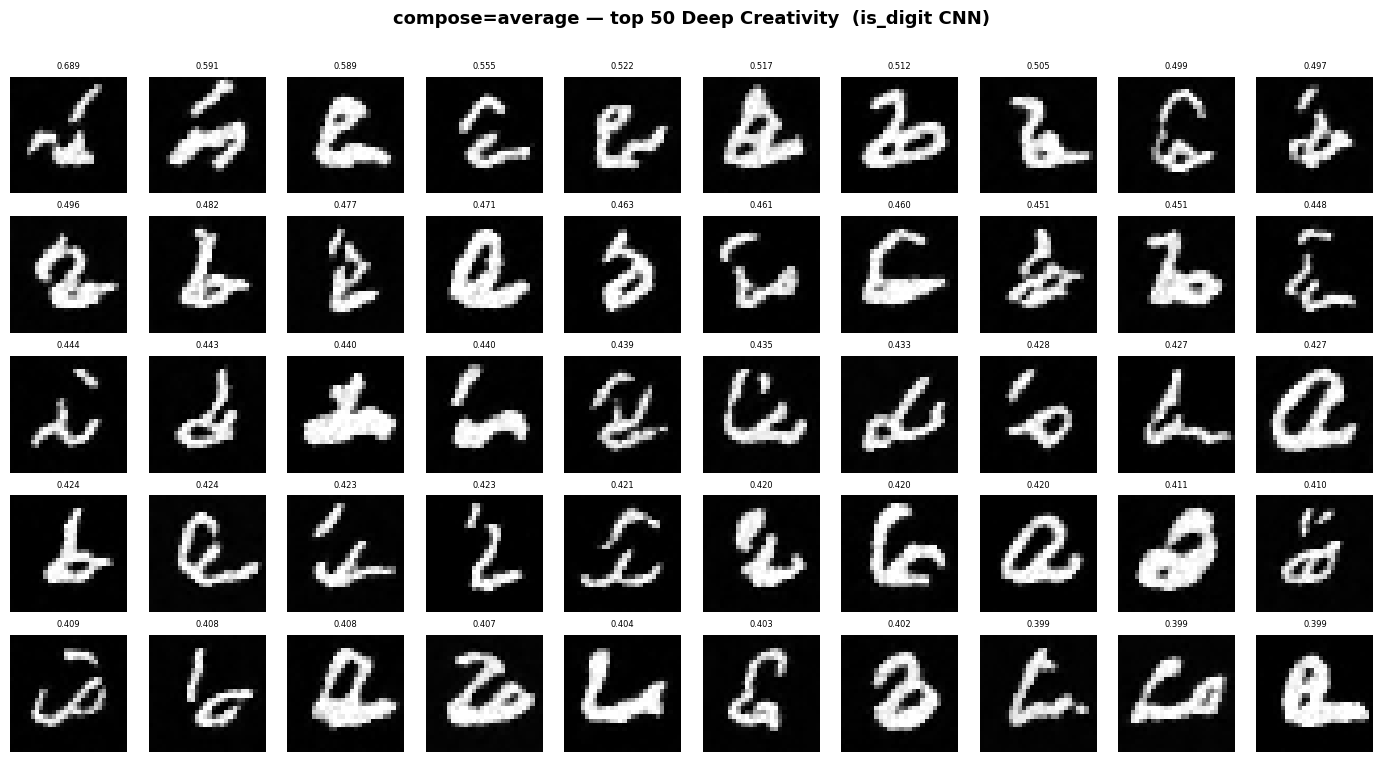

In [18]:
r = results[('average', 'cnn')]
fig = show_grid(r['top_imgs'], 'compose=average \u2014 top 50 Deep Creativity  (is_digit CNN)', scores=r['top_scores'])
fig.savefig(HERE / 'dc_top50_compose_average_cnn.png', bbox_inches='tight', dpi=120)
plt.show()

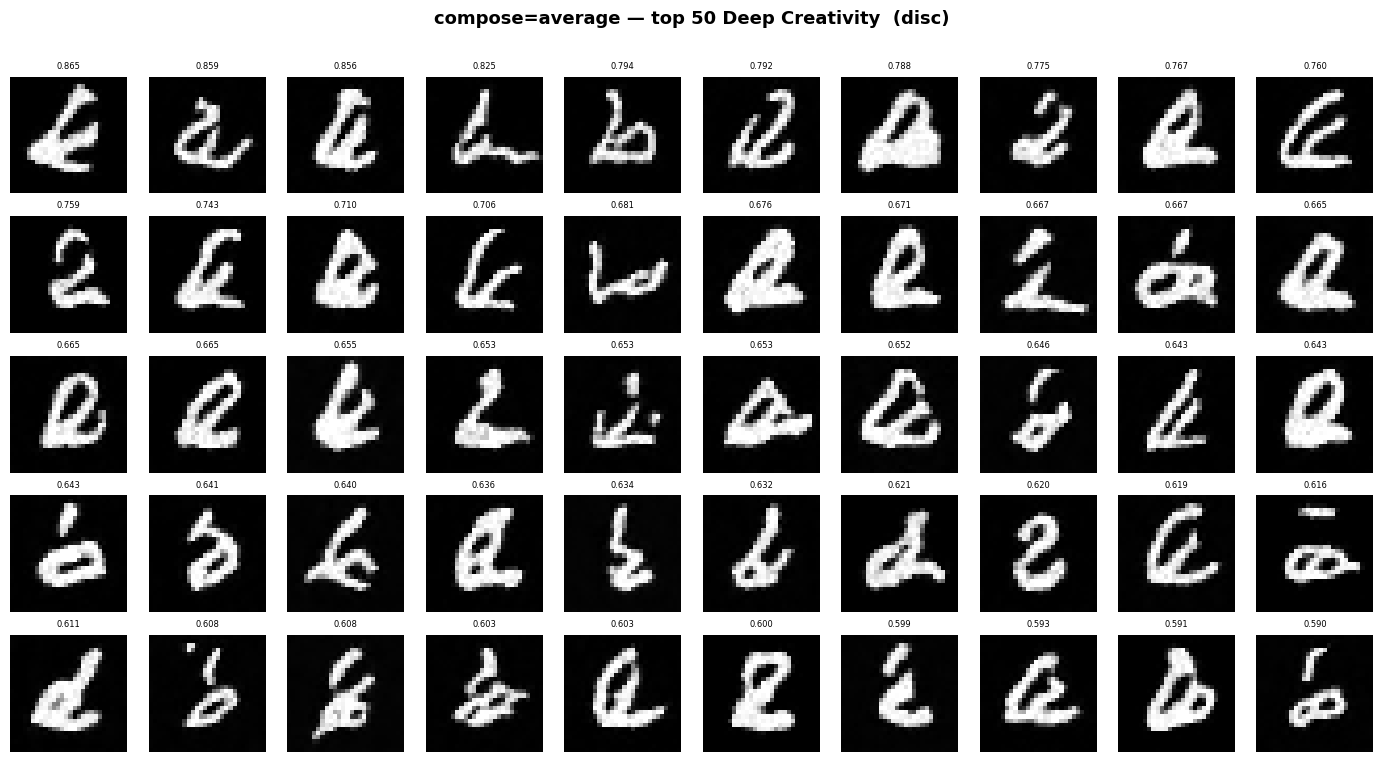

In [21]:
r = results[('average', 'disc')]
fig = show_grid(r['top_imgs'], 'compose=average \u2014 top 50 Deep Creativity  (disc)', scores=r['top_scores'])
fig.savefig(HERE / 'dc_top50_compose_average_disc.png', bbox_inches='tight', dpi=120)
plt.show()

## mode = product

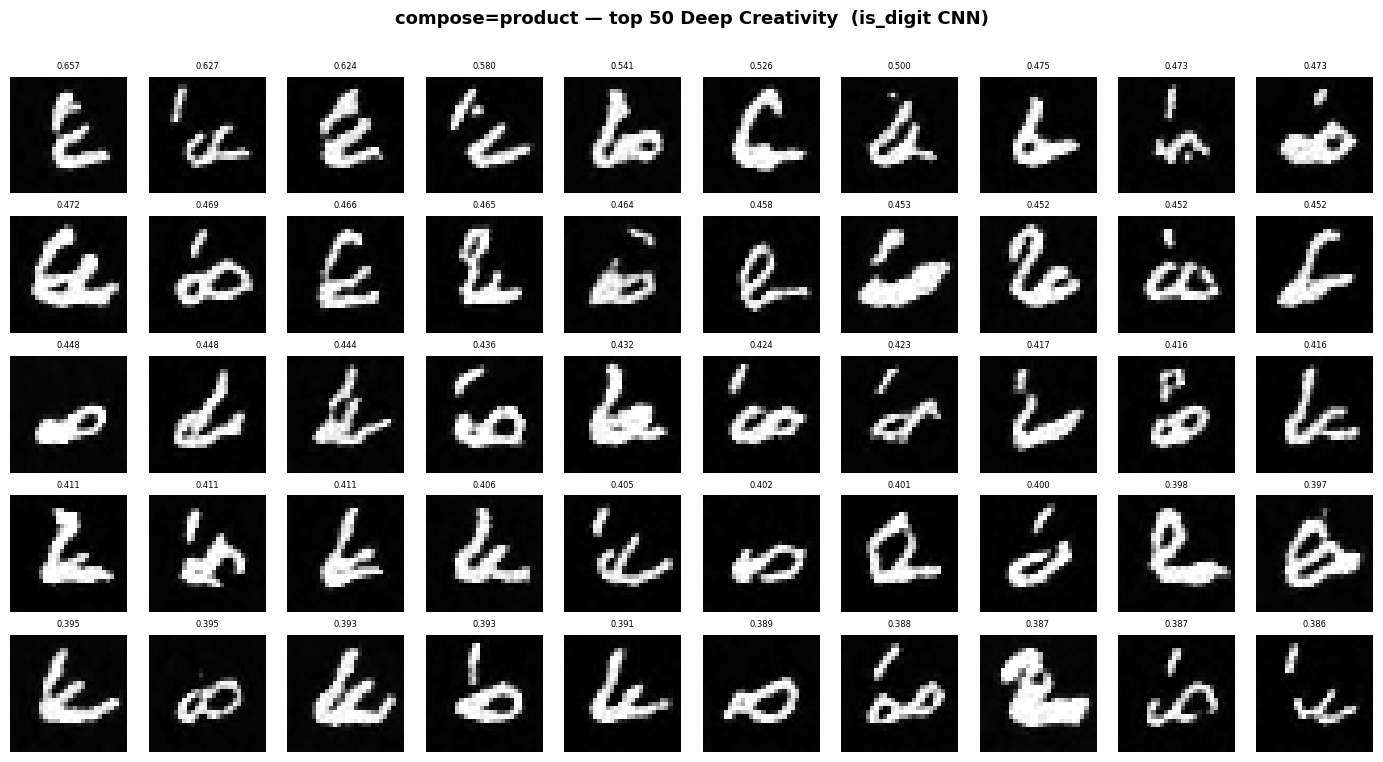

In [19]:
r = results[('product', 'cnn')]
fig = show_grid(r['top_imgs'], 'compose=product \u2014 top 50 Deep Creativity  (is_digit CNN)', scores=r['top_scores'])
fig.savefig(HERE / 'dc_top50_compose_product_cnn.png', bbox_inches='tight', dpi=120)
plt.show()

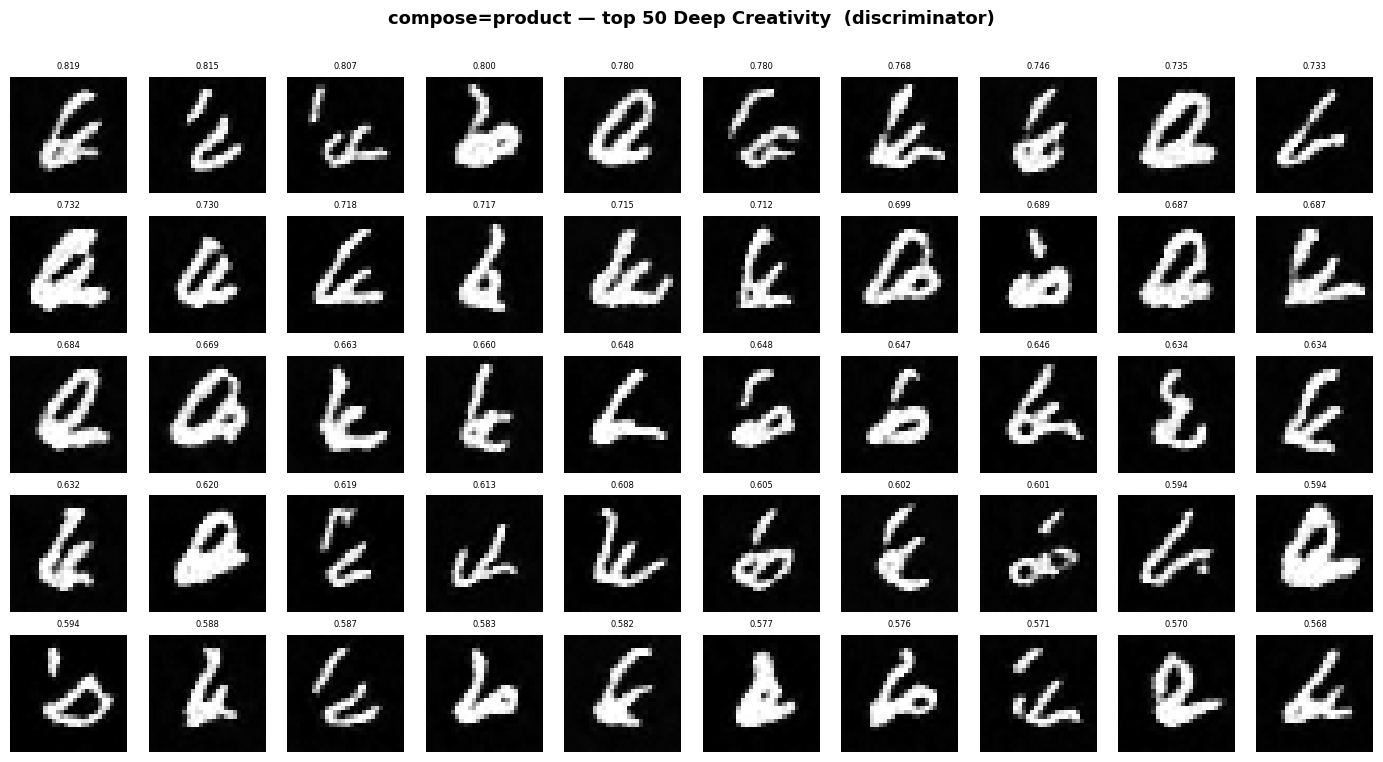

In [20]:
r = results[('product', 'disc')]
fig = show_grid(r['top_imgs'], 'compose=product \u2014 top 50 Deep Creativity  (discriminator)', scores=r['top_scores'])
fig.savefig(HERE / 'dc_top50_compose_product_disc.png', bbox_inches='tight', dpi=120)
plt.show()